# Car Evaluation using Neural Network

## Dataset: Car Evaluation - UC Irvine Machine Learning Repository
The Car Evaluation dataset contains information on various car attributes and a target label that categorizes the car as either unacceptable, acceptable, good, or very good. This project aims to classify cars using a multilayer neural network.

### Dataset Features
- **Buying**: Cost of buying the car (vhigh, high, med, low)
- **Maint**: Maintenance cost (vhigh, high, med, low)
- **Doors**: Number of doors (2, 3, 4, 5more)
- **Persons**: Capacity in terms of persons (2, 4, more)
- **Lug Boot**: Size of luggage boot (small, med, big)
- **Safety**: Estimated safety of the car (low, med, high)
- **Target Class**: Car acceptability (unacceptable, acceptable, good, very good)


In [ ]:
pip install --upgrade scikit-learn

In [ ]:
pip install ucimlrepo

### Step 1: Import Libraries and Load Dataset
This section covers the essential libraries for data handling, visualization, preprocessing, and model building. **NumPy** and **Pandas** are used for data manipulation, while **Matplotlib** and **Seaborn** aid in data visualization. **TensorFlow** is the framework for creating and training our neural network model. **Scikit-learn** provides tools for model evaluation, data scaling, and encoding of categorical data. Lastly, the **ucimlrepo** library allows direct access to datasets from the UCI Machine Learning Repository.

In [ ]:
# Import libraries for data manipulation and numerical operations
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Import TensorFlow for building neural network models
import tensorflow as tf

# Import scikit-learn modules for model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve
from sklearn.utils import class_weight, resample
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler

# Import Keras utilities for neural network support
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# Import dataset utility from the UCI Machine Learning Repository
from ucimlrepo import fetch_ucirepo

### Step 2: Load and Prepare the Dataset
In this step, we retrieve the Car Evaluation dataset from the UCI Machine Learning Repository using the `fetch_ucirepo` function, specifying the dataset ID. We separate the dataset into features (`X`) and target labels (`y`). The features are organized into a DataFrame for clarity, with column names set according to the dataset’s variables. Additionally, the target class is appended as a new column for easy access and analysis.

In [ ]:
# Fetch the Car Evaluation dataset by ID from UCI Machine Learning Repository
car_evaluation = fetch_ucirepo(id=19)

# Extract features and target labels from the dataset
X = car_evaluation.data.features
y = car_evaluation.data.targets

# Create a DataFrame for feature data with column names for readability
df = pd.DataFrame(X, columns=car_evaluation.variables.name)

# Append the target class to the DataFrame for easy data manipulation
df["class"] = y
df  # Display the DataFrame

name,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


### Step 3: Map Categorical Values to Descriptive Labels
This step involves translating the original categorical values in the dataset into more descriptive terms to enhance readability. We define three dictionaries to map values for the `buying`, `maint`, and `safety` attributes (using `general_map`), `lug_boot` size (using `lug_boot_map`), and target class labels (using `target_map`). These mappings are then applied to the relevant DataFrame columns, replacing abbreviations with full terms, making the dataset more interpretable.

In [ ]:
# Define dictionaries for mapping original categorical values to descriptive labels
general_map = { "low" : "low", "med" : "medium", "high" : "high", "vhigh": "very high" }
lug_boot_map = { "small" : "small", "med" : "medium", "big" : "big" }
target_map = { "unacc" : "unacceptable", "acc" : "acceptable", "good" : "good", "vgood": "very good" }

# Map 'lug_boot' values to descriptive labels
df["lug_boot"] = df["lug_boot"].map(lug_boot_map)

# Map target 'class' labels to descriptive labels
df["class"] = df["class"].map(target_map)

# Apply general mapping to 'buying', 'maint', and 'safety' columns
for column in ["buying", "maint", "safety"]:
    df[column] = df[column].map(general_map)

# Display the updated DataFrame with mapped values
df

name,buying,maint,doors,persons,lug_boot,safety,class
0,very high,very high,2,2,small,low,unacceptable
1,very high,very high,2,2,small,medium,unacceptable
2,very high,very high,2,2,small,high,unacceptable
3,very high,very high,2,2,medium,low,unacceptable
4,very high,very high,2,2,medium,medium,unacceptable
...,...,...,...,...,...,...,...
1723,low,low,5more,more,medium,medium,good
1724,low,low,5more,more,medium,high,very good
1725,low,low,5more,more,big,low,unacceptable
1726,low,low,5more,more,big,medium,good


### Step 4: Visualize Class Distribution
This step involves creating a bar chart to display the distribution of samples across the target classes. Using **Matplotlib** and **Seaborn**, we plot the counts of each unique label in the target variable to assess the balance of the dataset. This visualization is essential for identifying any class imbalance, as it can impact model training and evaluation, providing insight into the dataset before moving forward with model development.

<ipython-input-28-ed7644e370aa>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, palette="Set2")


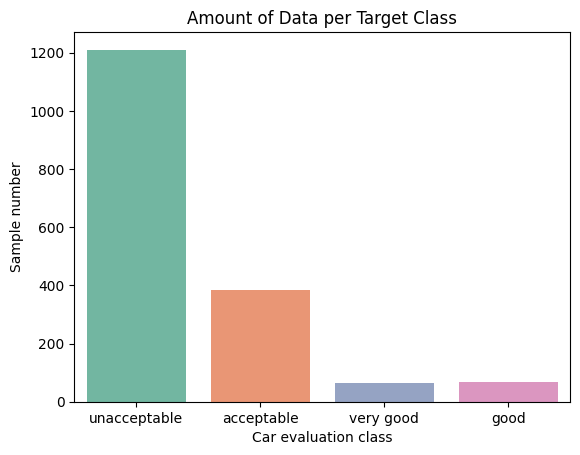

In [ ]:
# Define a function to plot the distribution of samples across target classes
def data_balance_graphic(df):
    # Set up the plot figure
    plt.figure()

    # Create a count plot to show the number of samples per target class
    sns.countplot(x="class", data=df, palette="Set2")

    # Set title and labels for clarity
    plt.title("Amount of Data per Target Class")
    plt.xlabel("Car evaluation class")
    plt.ylabel("Sample number")

    # Display the plot
    plt.show()

# Call the function to visualize the class distribution
data_balance_graphic(df)

### Step 5: Balance the Dataset
In this step, we address class imbalance by downsampling the majority class ("unacceptable") and upsampling the minority classes ("good" and "very good"). Using the `resample` function, we match the sample count of each class to that of the "acceptable" class. This balanced dataset prevents model bias toward the majority class, promoting better model performance. The resulting balanced DataFrame combines the downsampled and upsampled classes, creating a more equal distribution across target classes.

In [ ]:
# Separate the dataset into individual classes for resampling
majority = df[df["class"] == "unacceptable"]
acceptable = df[df["class"] == "acceptable"]
good = df[df["class"] == "good"]
vgood = df[df["class"] == "very good"]

# Downsample the majority class to match the size of the 'acceptable' class
majority_downsampled = resample(majority, replace=False, n_samples=len(acceptable), random_state=42)

# Upsample the minority classes to match the size of the 'acceptable' class
good_upsampled = resample(good, replace=True, n_samples=len(acceptable), random_state=42)
vgood_upsampled = resample(vgood, replace=True, n_samples=len(acceptable), random_state=42)

# Combine the resampled classes into a new balanced DataFrame
balanced_df = pd.concat([majority_downsampled, acceptable, good_upsampled, vgood_upsampled])
balanced_df  # Display the balanced DataFrame

name,buying,maint,doors,persons,lug_boot,safety,class
101,very high,very high,5more,more,small,high,unacceptable
504,high,very high,4,more,small,low,unacceptable
352,very high,low,3,2,small,medium,unacceptable
109,very high,high,2,2,small,medium,unacceptable
812,high,low,4,2,small,high,unacceptable
...,...,...,...,...,...,...,...
1562,low,medium,3,more,medium,high,very good
1565,low,medium,3,more,big,high,very good
1448,low,high,3,4,big,high,very good
1187,medium,medium,5more,more,big,high,very good


### Step 6: Prepare the Balanced Dataset
After balancing the dataset, we separate the features (`X_balanced`) from the target labels (`y_balanced`). We drop the class column to create the feature set and assign the class column as the target variable. We also confirm the balanced distribution of target classes by visualizing it with the `data_balance_graphic` function. This final preparation step ensures the dataset is ready for model training with equal class representation.

<ipython-input-28-ed7644e370aa>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, palette="Set2")


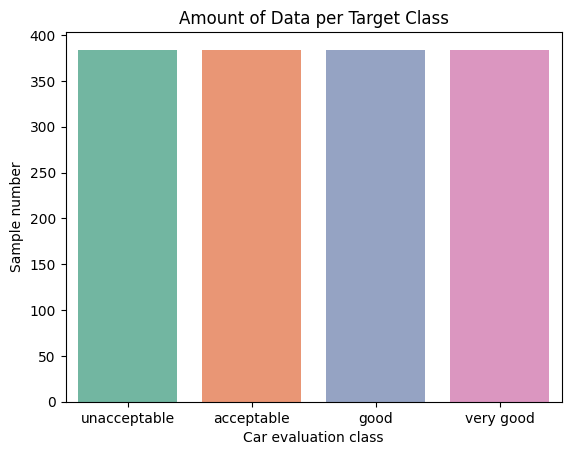

In [ ]:
# Visualize the balanced class distribution to confirm successful resampling
data_balance_graphic(balanced_df)

# Separate features and target labels for the balanced dataset
X_balanced = balanced_df.drop("class", axis=1)  # Create the feature set
y_balanced = balanced_df["class"]  # Define the target variable

### Step 7: Encode Categorical Variables
In this step, we utilize **LabelEncoder** from `sklearn` to convert categorical variables into numerical form, as machine learning models require numerical input. We apply the encoder to each column in the DataFrame, transforming all categorical values into integers. This encoding process ensures that the dataset is ready for efficient model processing.

In [ ]:
# Initialize label encoder for converting categorical values to numerical labels
label_encoder = LabelEncoder()

# Apply the encoder to each column to transform categorical data into integer values
for column in balanced_df.columns:
    balanced_df[column] = label_encoder.fit_transform(balanced_df[column])

# Display the DataFrame with encoded values
balanced_df

name,buying,maint,doors,persons,lug_boot,safety,class
101,3,3,3,2,2,0,2
504,0,3,2,2,2,1,2
352,3,1,1,0,2,2,2
109,3,0,0,0,2,2,2
812,0,1,2,0,2,0,2
...,...,...,...,...,...,...,...
1562,1,2,1,2,1,0,3
1565,1,2,1,2,0,0,3
1448,1,0,1,1,0,0,3
1187,2,2,3,2,0,0,3


### Step 8: Visualize the Correlation Matrix
In this step, we create a **heatmap** to visualize the correlation between features in the dataset. Using `Seaborn's` *heatmap* function, we display the correlation matrix, which illustrates the relationships among different attributes. The heatmap is annotated with correlation coefficients and utilizes the "coolwarm" color map to indicate the strength of these correlations. This visualization offers valuable insights into how various features relate to one another, which can significantly impact model performance.

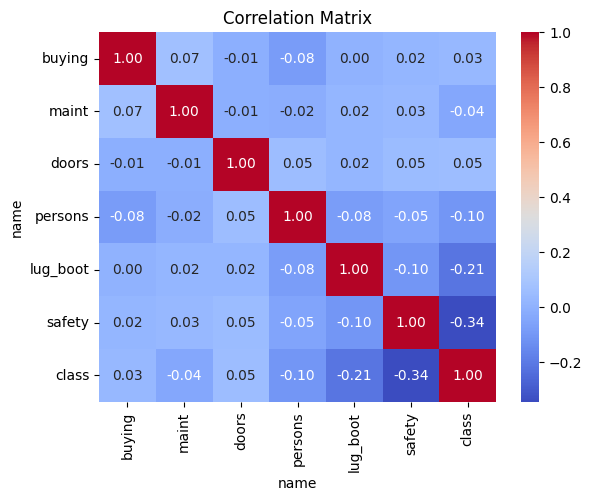

In [ ]:
# Set up the plot figure for the correlation matrix
plt.figure()

# Calculate the correlation matrix of the balanced DataFrame
correlation_matrix = balanced_df.corr()

# Create a heatmap to visualize the correlations between features
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Set the title for the heatmap
plt.title("Correlation Matrix")

# Display the heatmap
plt.show()

### Step 9: One-Hot Encoding and Splitting the Dataset
In this step, we apply one-hot encoding to the target variable `y` using the `pd.get_dummies()` function. This transformation converts categorical variables into a binary format, making it suitable for neural network interpretation. After encoding, we split the dataset into training and testing sets with `train_test_split`, allocating 30% of the data for testing. This division is essential for evaluating the model's performance on unseen data, ensuring a robust assessment of its generalization capabilities.

In [ ]:
# Perform one-hot encoding on the target variable to convert categories into binary format
y = pd.get_dummies(y_balanced).values

# Split the balanced DataFrame into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    balanced_df.drop("class", axis=1),  # Features
    y,  # Target variable
    test_size=0.3,  # 30% of data for testing
    random_state=42  # For reproducibility
)

### Step 10: Build the Neural Network Model
In this step, we construct a sequential neural network model using TensorFlow's Keras API. The model comprises five dense layers: the first four layers have 64, 32, 16 and 8 units, respectively, utilizing the `relu` activation function to capture non-linear relationships. Each of these layers incorporates L2 regularization to mitigate overfitting by penalizing large weights. The output layer consists of 4 units and employs the `softmax` activation function to produce class probabilities. We compile the model using the Adam optimizer and the categorical crossentropy loss function, along with the F1 score metric, which is valuable for evaluating performance in multi-class classification tasks.

In [ ]:
# Initialize a sequential neural network model
model = tf.keras.Sequential()

# Add the hidden layers with various units, 'relu' activation, and L2 regularization
model.add(tf.keras.layers.Dense(units=64, activation="relu", input_dim=X_train.shape[1], kernel_regularizer=l2(0.01)))
model.add(tf.keras.layers.Dense(units=32, activation="relu", kernel_regularizer=l2(0.01)))
model.add(tf.keras.layers.Dense(units=16, activation="relu", kernel_regularizer=l2(0.01)))
model.add(tf.keras.layers.Dense(units=8, activation="relu", kernel_regularizer=l2(0.01)))

# Add the output layer with 4 units and 'softmax' activation for multi-class classification
model.add(tf.keras.layers.Dense(units=4, activation="softmax"))

# Compile the model with Adam optimizer and categorical crossentropy loss
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["f1_score"])

### Step 11: Train the Model
In this step, we train the neural network model using the training dataset. The `fit` method is invoked on the model, specifying the training features (`X_train`) and target labels (`y_train`). We reserve 20% of the training data for validation to monitor the model's performance throughout the training process. The training is conducted over 150 epochs with a batch size of 16, allowing the model to learn from subsets of data in each iteration. The `verbose=1` parameter ensures that training progress is displayed in the output, providing insights into the training process, including loss and accuracy metrics for both training and validation sets.

In [ ]:
# Train the neural network model using the training dataset
history = model.fit(
    X_train,  # Training features
    y_train,  # Training target labels
    validation_split=0.2,  # Reserve 20% of the data for validation
    batch_size=16,  # Set batch size to 16
    epochs=150,  # Train for 150 epochs
    verbose=1  # Display training progress
)

Epoch 1/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - f1_score: 0.3146 - loss: 2.1231 - val_f1_score: 0.4278 - val_loss: 1.8289
Epoch 2/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.4853 - loss: 1.7449 - val_f1_score: 0.4819 - val_loss: 1.5658
Epoch 3/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.5537 - loss: 1.5117 - val_f1_score: 0.5110 - val_loss: 1.4126
Epoch 4/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.5478 - loss: 1.3755 - val_f1_score: 0.4860 - val_loss: 1.3227
Epoch 5/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.5744 - loss: 1.2751 - val_f1_score: 0.4968 - val_loss: 1.2749
Epoch 6/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.5849 - loss: 1.2229 - val_f1_score: 0.5308 - val_loss: 1.2247
Epoch 7/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.6138 - loss: 1.1608 - val_f1_score: 0.5656 - val_loss: 1.1919
Epoch 8/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_score: 0.5812 - loss: 1.1700 - val_f1_score: 0.5663 - v

### Step 12: Visualizing Model Performance
In this step, we visualize the model's performance by plotting the F1 score and loss over the training epochs. We create a figure with two subplots: the first subplot displays the training and validation F1 scores, while the second subplot illustrates the training and validation loss. The `range` function is utilized to generate epoch numbers for the x-axis. Each plot is labeled with appropriate titles and axes, providing a clear view of how the model's F1 score and loss evolve throughout the training process. This visualization aids in assessing the model's ability to generalize, indicating potential overfitting or underfitting based on the observed trends.

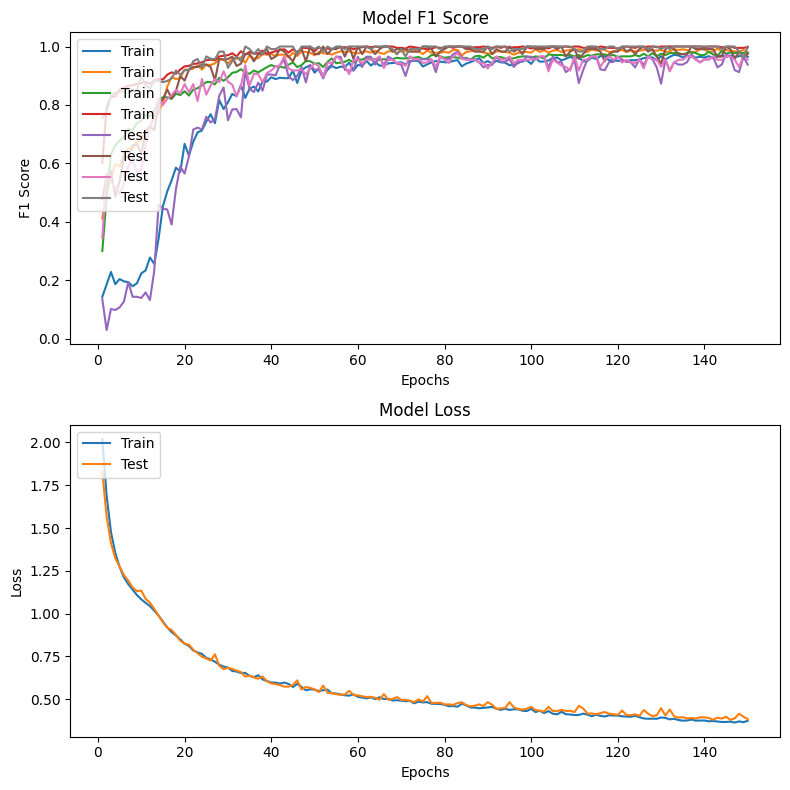

In [ ]:
# Generate epoch numbers for the x-axis
epochs = range(1, len(history.history['f1_score']) + 1)

# Create subplots for visualizing F1 score and loss
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# Plot F1 scores
ax1.plot(epochs, history.history["f1_score"], label="Train")  # Training F1 Score
ax1.plot(epochs, history.history["val_f1_score"], label="Test")  # Validation F1 Score
ax1.set_title("Model F1 Score")  # Title for F1 Score plot
ax1.set_ylabel("F1 Score")  # Y-axis label
ax1.set_xlabel("Epochs")  # X-axis label
ax1.legend(loc="upper left")  # Legend location

# Plot loss
ax2.plot(epochs, history.history["loss"], label="Train")  # Training Loss
ax2.plot(epochs, history.history["val_loss"], label="Test")  # Validation Loss
ax2.set_title("Model Loss")  # Title for Loss plot
ax2.set_ylabel("Loss")  # Y-axis label
ax2.set_xlabel("Epochs")  # X-axis label
ax2.legend(loc="upper left")  # Legend location

# Adjust layout and display the plots
plt.tight_layout()  # Ensure proper spacing
plt.show()  # Show the plots

### Step 13: Evaluating the Model
In this step, we evaluate the trained neural network model using the test dataset. The `evaluate` method is called with the testing features (`X_test`) and target labels (`y_test`) to compute the loss and F1 score. The evaluation is performed silently by setting `verbose=0`. After evaluation, we print the test loss and F1 score, providing insight into the model's performance on unseen data. This assessment is crucial for understanding how well the model generalizes to new instances and for determining its effectiveness in the classification task.

In [ ]:
# Evaluate the model on the test dataset
loss, f1 = model.evaluate(X_test, y_test, verbose=0)  # Compute loss and F1 score silently

# Print the evaluation results
print(f"Test loss: {loss}")  # Output the test loss
print(f"Test F1 score: {f1}")  # Output the test F1 score

Test loss: 0.36973387002944946
Test F1 score: [0.9406779  0.9754098  0.96261674 1.        ]


### Step 14: Making Predictions and Comparing Results
In this step, we use the trained model to make predictions on the test dataset by calling the `predict` method with the test features (`X_test`). The predicted probabilities for each class are obtained, and we convert these probabilities into class labels by using `np.argmax` to retrieve the index of the maximum value for both the true labels (`y_test`) and the predicted labels (`y_pred`). Finally, we print the expected class labels and the predicted class labels, allowing us to compare the model's predictions against the actual outcomes. This comparison is essential for evaluating the model's accuracy and understanding its performance on the classification task.


In [ ]:
# Make predictions on the test dataset
y_pred = model.predict(X_test)  # Get predicted probabilities for each class

# Convert the one-hot encoded true labels and predicted labels into class indices
y_expected = np.argmax(y_test, axis=1)  # Retrieve true class labels
y_predicted = np.argmax(y_pred, axis=1)  # Retrieve predicted class labels

# Print the expected and predicted class labels
print(f"Expected: {y_expected}")  # Output the true class labels
print(f"Predicted: {y_predicted}")  # Output the predicted class labels

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Expected: [3 2 2 1 3 1 0 3 1 3 1 0 2 3 3 3 1 2 2 2 2 2 2 2 1 2 1 0 1 1 0 1 0 0 3 3 0
 0 1 3 3 1 0 0 2 2 2 0 3 1 2 1 1 3 3 0 2 3 2 0 2 0 2 0 1 0 1 1 0 2 1 0 3 2
 2 3 1 0 3 2 3 1 0 2 1 2 2 3 0 1 3 0 2 3 1 0 3 0 0 0 1 3 2 3 0 3 1 1 0 3 2
 1 2 1 3 2 1 1 3 1 3 2 0 1 3 0 2 0 1 3 0 1 1 1 1 2 3 2 1 1 2 3 1 3 0 0 0 0
 2 3 3 1 1 0 1 2 0 3 2 1 3 3 3 0 2 3 2 1 1 1 1 1 1 1 2 3 0 2 1 3 0 2 1 0 0
 0 2 0 1 2 1 3 2 3 1 1 0 3 2 2 2 3 0 2 2 1 0 1 0 0 2 2 1 0 3 3 3 2 0 1 0 3
 0 2 1 0 2 0 0 0 1 3 3 1 2 3 1 1 2 0 1 1 1 1 2 0 3 1 2 1 2 3 3 2 0 2 0 3 0
 2 1 3 2 0 0 3 0 0 0 0 2 0 0 0 3 3 1 2 3 3 2 0 1 3 0 1 2 2 1 2 2 1 1 0 3 3
 0 3 1 3 0 0 3 1 3 2 1 2 1 3 2 3 2 3 2 3 1 1 0 3 0 2 0 0 1 0 1 2 2 3 1 0 2
 3 3 1 1 0 3 0 1 3 2 2 1 1 1 0 0 3 0 1 2 3 2 2 3 0 3 0 0 0 2 2 3 3 2 0 2 3
 2 3 2 3 0 3 2 0 2 1 1 0 1 1 1 1 3 2 3 1 1 3 3 1 2 1 2 1 2 0 3 0 3 1 3 3 3
 2 0 3 0 0 1 2 3 3 2 3 0 1 0 3 0 0 1 2 1 0 3 1 1 3 3 0 2 0 1 0 0 2 2 1 0 0
 2 1 3 2 0 3 2 0 0 3 2 3 2 0 3 1 1]
Predicted: [3 2

### Step 15: Calculating Classification Metrics
In this step, we evaluate the model's performance using several important classification metrics: **precision**, **recall**, **F1-score**, and **accuracy**. We calculate these metrics with a macro average, which gives equal weight to each class, regardless of their frequency in the dataset. This approach is particularly useful in scenarios with class imbalance. After computing these metrics, they are printed with two decimal precision to provide a detailed overview of the model's effectiveness in correctly classifying the test dataset. These metrics help to further assess the quality of the model beyond accuracy alone.

In [ ]:
# Binarize the expected and predicted class labels for AUC calculation
y_expected_bin = label_binarize(y_expected, classes=[0, 1, 2, 3])  # Convert true labels to binary format
y_predicted_bin = label_binarize(y_predicted, classes=[0, 1, 2, 3])  # Convert predicted labels to binary format

# Calculate classification metrics
precision_macro = precision_score(y_expected, y_predicted, average="macro")  # Calculate precision
recall_macro = recall_score(y_expected, y_predicted, average="macro")  # Calculate recall
f1_macro = f1_score(y_expected, y_predicted, average="macro")  # Calculate F1-score
accuracy = accuracy_score(y_expected, y_predicted)  # Calculate accuracy
auc = roc_auc_score(y_expected_bin, y_predicted_bin, multi_class="ovr")  # Calculate AUC

# Print classification metrics with two decimal precision
print(f"Precision (Macro): {precision_macro:.2f}")  # Output macro precision
print(f"Recall (Macro): {recall_macro:.2f}")  # Output macro recall
print(f"F1-Score (Macro): {f1_macro:.2f}")  # Output macro F1-score
print(f"Accuracy (Accuracy): {accuracy:.2f}")  # Output overall accuracy
print(f"AUC (OvR): {auc:.2f}")  # Output Area Under the Curve (AUC)

Precision (Macro): 0.97
Recall (Macro): 0.97
F1-Score (Macro): 0.97
Accuracy (Accuracy): 0.97
AUC (OvR): 0.98


### Step 16: Visualizing the Confusion Matrix
In this step, we create a confusion matrix to visualize the model's performance in classifying the test dataset. We generate the confusion matrix using the `confusion_matrix` function by comparing the expected and predicted labels. The confusion matrix is then displayed as a matrix plot using Matplotlib. We add titles and labels for clarity, indicating the true and predicted class labels. This visualization provides a comprehensive view of the classification performance, allowing us to see where the model is correctly predicting classes and where it is making errors, thus highlighting areas for potential improvement.

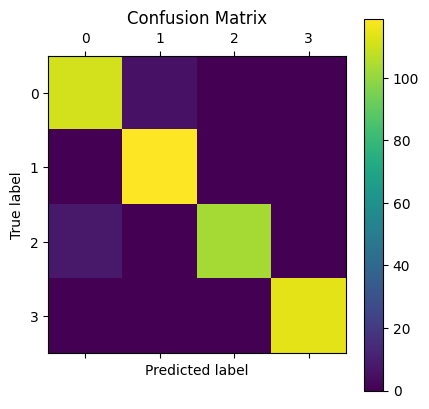

In [ ]:
# Generate the confusion matrix from expected and predicted labels
cm = confusion_matrix(y_expected, y_predicted)  # Compute confusion matrix

# Visualize the confusion matrix using a matrix plot
plt.matshow(cm)  # Create a matrix plot for the confusion matrix

# Add titles and labels for clarity
plt.title('Confusion Matrix')  # Title of the plot
plt.colorbar()  # Add color bar to indicate scale
plt.ylabel('True label')  # Label for true class
plt.xlabel('Predicted label')  # Label for predicted class

plt.show()  # Display the plot

### Step 17: Visualizing the ROC Curves for Multiclass Classification
In this step, we visualize the ROC (Receiver Operating Characteristic) curves for each class in a multiclass classification problem. The ROC curve plots the true positive rate (TPR) against the false positive rate (FPR), providing a graphical representation of the model's performance at different thresholds. This visualization allows us to assess the trade-off between sensitivity and specificity for each class.

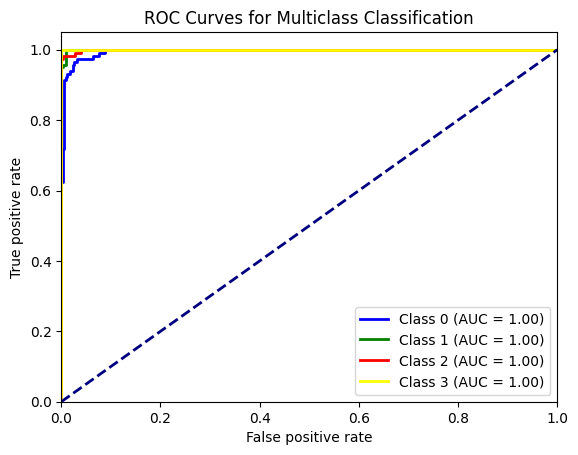

In [ ]:
# Number of classes in the classification problem
n_classes = 4

# Dictionaries to hold false positive rates, true positive rates, and ROC AUC values
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

# Calculate FPR, TPR, and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_expected_bin[:, i], y_pred[:, i])  # Compute ROC curve
    roc_auc[i] = roc_auc_score(y_expected_bin[:, i], y_pred[:, i])  # Compute AUC

# Create a new figure for the ROC curves
plt.figure()
colors = ["blue", "green", "red", "yellow"]  # Colors for each class

# Plot the ROC curve for each class
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"Class {i} (AUC = {roc_auc[i]:.2f})")  # Plot ROC

# Plot a diagonal line for reference
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])  # Set x-axis limits
plt.ylim([0.0, 1.05])  # Set y-axis limits

# Add labels and title
plt.xlabel("False positive rate")  # X-axis label
plt.ylabel("True positive rate")  # Y-axis label
plt.title("ROC Curves for Multiclass Classification")  # Title of the plot

# Show legend and display the plot
plt.legend(loc="lower right")
plt.show()  # Display the ROC curves